# 03 - Training the Isolation Forest

**What you will learn**
- How Isolation Forest works, at the intuition level.
- How to split a run-to-failure dataset into a "healthy-only" subset for
  unsupervised training.
- How to score every cycle and interpret the resulting anomaly score.
- How to pick a threshold when you have no labels.
- How to translate the raw score into a per-engine "cycles-before-failure
  the alarm fired" number, which is the metric we actually care about.

## Isolation Forest in one paragraph

An Isolation Forest is an ensemble of random binary trees. To score a point
`x`, each tree keeps splitting the data along random features at random
thresholds until `x` is alone in a leaf. **The number of splits needed to
isolate `x` is the tree's "score"** (short = anomaly, long = normal).
Anomalies tend to sit far from the crowd, so they fall into their own leaf
after only a few splits. Averaging across the ensemble smooths the score.
The whole thing is unsupervised: it only needs feature vectors, not labels.

Why this suits our problem: we have plenty of examples of *normal* (early-
life cycles) and we want to flag anything that "looks different" from that,
without ever labelling cycles as anomalous. That is exactly what Isolation
Forest optimises for.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

from src.models import fit_isolation_forest, anomaly_score

## 1. Load the feature matrix built in notebook 02

If `data/features_train.csv` does not exist yet, go re-run notebook 02 end
to end. It builds and saves the matrix.

In [2]:
feat = pd.read_csv(ROOT / "data" / "features_train.csv")
feature_cols = [c for c in feat.columns if c not in ("unit", "cycle", "regime", "rul")]

print(f"{len(feat):,} rows, {len(feature_cols)} features")
print("Feature columns:")
print(feature_cols)
feat.head()

61,249 rows, 20 features
Feature columns:
['s11_ewma', 's4_ewma', 's9_ewma', 's17_ewma', 's3_ewma', 's13_ewma', 's8_ewma', 's14_ewma', 's11_dev', 's4_dev', 's9_dev', 's17_dev', 's3_dev', 's13_dev', 's8_dev', 's14_dev', 's11_slope', 's4_slope', 's9_slope', 's17_slope']


,unit,cycle,regime,rul,s11_ewma,s4_ewma,s9_ewma,s17_ewma,s3_ewma,s13_ewma,...,s9_dev,s17_dev,s3_dev,s13_dev,s8_dev,s14_dev,s11_slope,s4_slope,s9_slope,s17_slope
0,1,1,0,320,-1.207006,-1.281784,-0.876629,-0.327361,-1.384507,-0.385986,...,0.149248,1.006507,-0.084078,0.922360,0.685986,0.087515,0.000000,0.000000,0.000000,0.000000
1,1,2,4,319,-1.233116,-1.291197,-0.876859,-0.571105,-1.322435,-0.576135,...,0.147409,-0.943448,0.412497,-0.598838,-0.366657,-0.340511,-0.208880,-0.075307,-0.001839,-1.949955
2,1,3,0,318,-1.242884,-1.232922,-0.908063,-0.615884,-1.336069,-0.562060,...,-0.100613,0.404533,-0.131073,0.844817,0.937193,-0.401298,-0.052127,0.228396,-0.124931,-0.300987
3,1,4,0,317,-1.242743,-1.168349,-0.897186,-0.730312,-1.383624,-0.525511,...,0.204833,-0.197440,-0.416079,1.038675,0.769722,0.160152,0.000037,0.222844,-0.008127,-0.226386
4,1,5,2,316,-1.195059,-1.242697,-0.965107,-0.798020,-1.327606,-0.588774,...,-0.414680,0.061895,0.364945,0.276733,0.383028,-0.002140,0.086560,-0.032195,-0.107043,-0.114322


## 2. Split into "healthy" (training) and "everything" (scoring)

**Why a split at all?** Isolation Forest is unsupervised, but "unsupervised"
does not mean "ignore what you know". We know the early cycles of every
engine were healthy (engines run to failure in this dataset, so early = far
from failure). Training on the healthy subset only, then scoring the whole
lifespan, lets the model learn what "normal" looks like without seeing
degraded examples that would water down its idea of normal.

**The definition of healthy** is a design choice with a clean physical
interpretation. Here: any cycle whose RUL is at least 100 is called healthy.
For a 300-cycle engine that means the first 200 cycles are training; the
last 100 are scored but not trained on. Cycles with RUL between the healthy
threshold and the anomaly threshold (100 down to 30) become an ambiguous
middle where neither label is asserted.

In [3]:
HEALTHY_THRESHOLD = 100  # cycles from failure

healthy = feat[feat["rul"] >= HEALTHY_THRESHOLD]
X_train = healthy[feature_cols].values
X_all = feat[feature_cols].values

print(f"Training rows (RUL >= {HEALTHY_THRESHOLD}): {len(X_train):,}")
print(f"Scoring rows (all cycles):                 {len(X_all):,}")
print(f"Training / total ratio:                    "
      f"{len(X_train)/len(X_all):.1%}")

Training rows (RUL >= 100): 36,349
Scoring rows (all cycles):                 61,249
Training / total ratio:                    59.3%


## 3. Fit the model

`src.models.fit_isolation_forest` is a thin wrapper around
`sklearn.ensemble.IsolationForest`. Two knobs worth knowing:

- `n_estimators=200`: the ensemble size. 100 is scikit-learn's default;
  200 gives smoother scores at the cost of about 2x fit time, and both
  numbers are cheap on 40k rows and 20 features.
- `contamination=0.02`: expected fraction of anomalies in the *training*
  data. Since we train on healthy-only cycles, this should be small.
  0.02 leaves the internal decision offset well-behaved without asserting
  that 2% of the healthy set is truly anomalous.

In [4]:
model = fit_isolation_forest(
    X_train, contamination=0.02, n_estimators=200, random_state=42,
)
print("Model:", model)

Model: IsolationForest(contamination=0.02, n_estimators=200, n_jobs=-1,
                random_state=42)


## 4. Score every cycle

`anomaly_score` returns a value where higher = more anomalous. It negates
sklearn's `score_samples` so the numbers read intuitively (small = normal,
big = weird).

In [5]:
scores = anomaly_score(model, X_all)
feat = feat.assign(score=scores)

print(f"Score range: [{scores.min():.3f}, {scores.max():.3f}]")
print(f"Score mean/std on healthy training subset: "
      f"{scores[feat['rul'] >= HEALTHY_THRESHOLD].mean():.3f} / "
      f"{scores[feat['rul'] >= HEALTHY_THRESHOLD].std():.3f}")
print(f"Score mean/std on near-failure subset (RUL <= 20): "
      f"{scores[feat['rul'] <= 20].mean():.3f} / "
      f"{scores[feat['rul'] <= 20].std():.3f}")

Score range: [0.357, 0.745]
Score mean/std on healthy training subset: 0.422 / 0.042
Score mean/std on near-failure subset (RUL <= 20): 0.675 / 0.057


**Reading those numbers.** The near-failure subset should have a
substantially higher mean score than the healthy training subset. If they
are identical, either the features carry no signal or the training scope is
wrong. If they differ noticeably, the detector is doing its job.

## 5. What does the score curve look like over a life?

Plot the score against the cycle number for a handful of engines. Overlay
the failure line so we can see how much before failure the score starts to
rise.

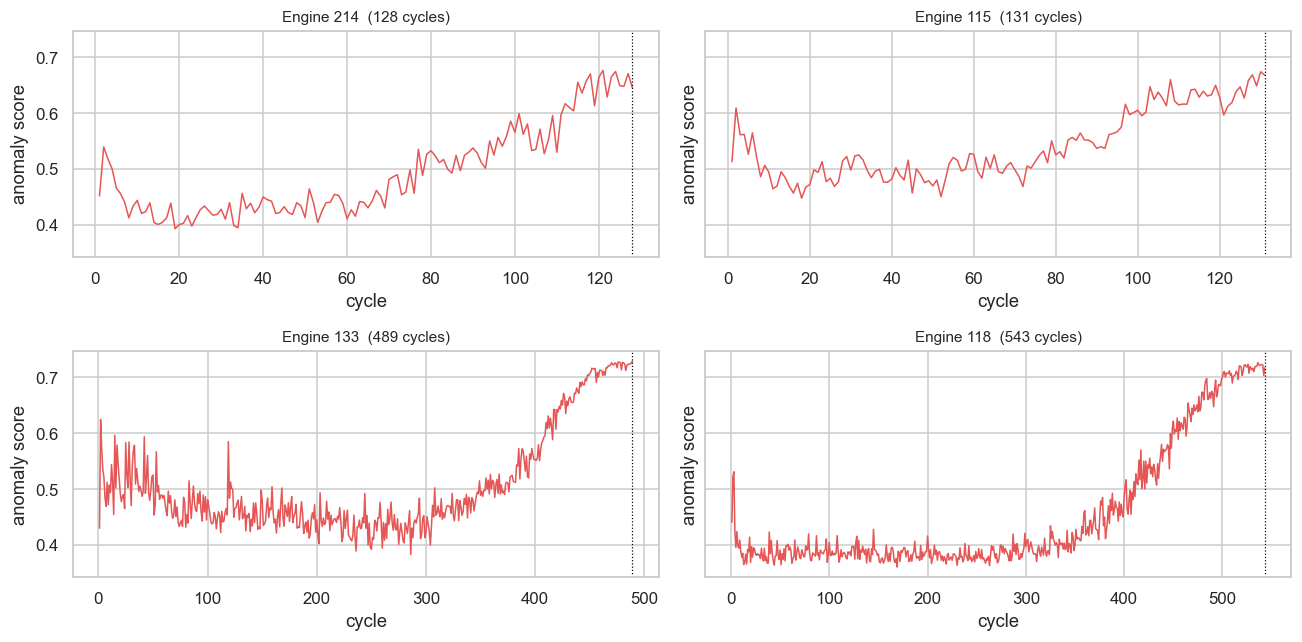

In [6]:
def score_over_life(feat, units, ncols=2):
    n = len(units)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(ncols * 6, nrows * 3), sharey=True,
    )
    axes = np.array(axes).flatten() if n > 1 else [axes]
    for ax, u in zip(axes, units):
        sub = feat[feat["unit"] == u].sort_values("cycle")
        ax.plot(sub["cycle"], sub["score"], color="#e45756", linewidth=1.0)
        ax.axvline(sub["cycle"].max(), color="black", linestyle=":",
                   linewidth=0.8, label="failure")
        ax.set_title(f"Engine {u}  ({sub['cycle'].max()} cycles)", fontsize=10)
        ax.set_xlabel("cycle")
        ax.set_ylabel("anomaly score")
    fig.tight_layout()
    plt.show()

# Pick a couple of engines spanning the lifespan range so the shape is clear
# across short and long trajectories.
lifespans = feat.groupby("unit")["cycle"].max().sort_values()
short_units = lifespans.head(2).index.tolist()
long_units = lifespans.tail(2).index.tolist()
score_over_life(feat, short_units + long_units, ncols=2)

**Reading the plot.** For a well-behaved detector on this dataset,
the score should be roughly flat and low for the first half or two-thirds
of each engine's life, then climb monotonically as failure approaches. Some
noise is normal, but the trend should be visible above the noise.

## 6. Pick a threshold

The score itself is not a decision - we still need a threshold: score above
it means "raise the alarm", score below means "carry on". Two natural ways
to pick it, and we do both:

1. **Quantile of the healthy score distribution.** If we accept a small
   false-positive rate on cycles we consider healthy, take the 95th
   percentile of scores on the training subset. Any score above that is by
   construction unusual compared to healthy cycles.
2. **Where the healthy and near-failure score distributions separate.**
   Overlay the histograms and pick a threshold in the gap between them.
   This is a visual sanity check on the quantile choice.

Threshold (95th percentile of healthy scores): 0.503


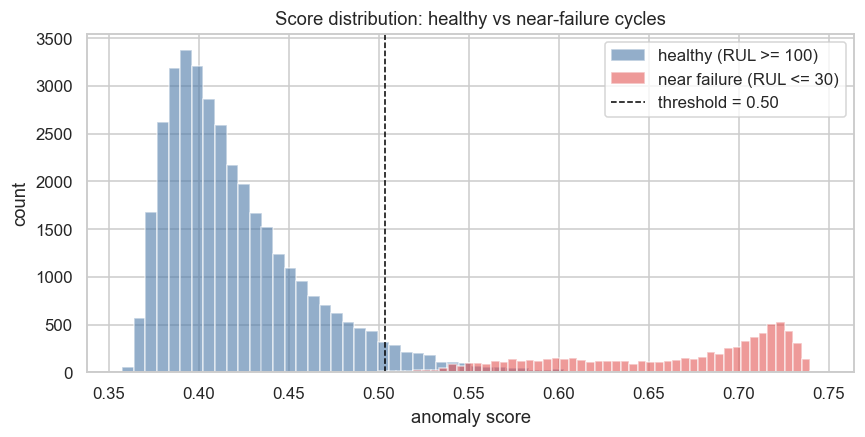

In [7]:
# Distributional threshold: 95th percentile of the healthy training scores.
healthy_scores = feat.loc[feat["rul"] >= HEALTHY_THRESHOLD, "score"]
near_failure_scores = feat.loc[feat["rul"] <= 30, "score"]
threshold = float(healthy_scores.quantile(0.95))
print(f"Threshold (95th percentile of healthy scores): {threshold:.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(healthy_scores, bins=60, alpha=0.6, color="#4c78a8",
        edgecolor="white", label=f"healthy (RUL >= {HEALTHY_THRESHOLD})")
ax.hist(near_failure_scores, bins=60, alpha=0.6, color="#e45756",
        edgecolor="white", label="near failure (RUL <= 30)")
ax.axvline(threshold, color="black", linestyle="--", linewidth=1.0,
           label=f"threshold = {threshold:.2f}")
ax.set_xlabel("anomaly score")
ax.set_ylabel("count")
ax.set_title("Score distribution: healthy vs near-failure cycles")
ax.legend()
plt.show()

**Reading the plot.** The two histograms should overlap on the left
(a few near-failure cycles happen to look normal) and separate on the right
(most healthy cycles score below the threshold, most near-failure cycles
score above). The gap between the two peaks is exactly what the detector
is learning to exploit.

## 7. How much lead time do we get?

For each engine, find the first cycle where its score crosses the threshold.
The cycles remaining until failure at that moment is the *lead time*: how
much warning did we get?

Engines flagged at least once: 249 / 249
Lead-time summary (cycles before failure at first flag):
count    249.0
mean     217.1
std       91.9
min       34.0
25%      165.0
50%      210.0
75%      272.0
max      541.0


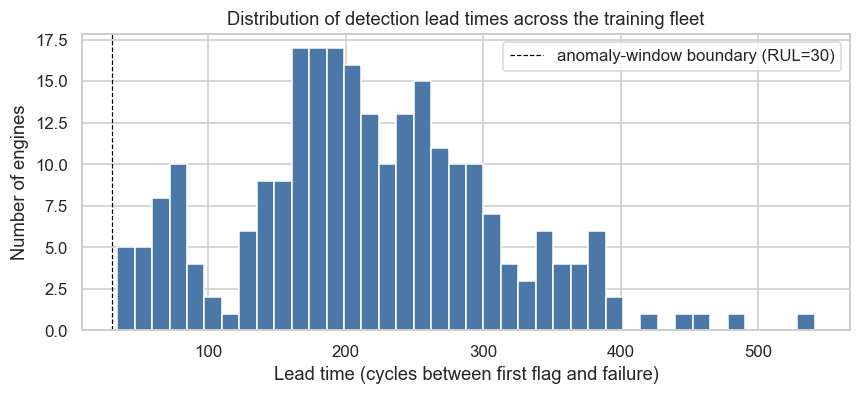

In [8]:
from src.evaluate import first_flag_lead_time

scores_df = feat[["unit", "cycle", "rul", "score"]]
lead = first_flag_lead_time(scores_df, threshold=threshold)
n_flagged = len(lead)
n_total = feat["unit"].nunique()
print(f"Engines flagged at least once: {n_flagged} / {n_total}")
print(f"Lead-time summary (cycles before failure at first flag):")
print(lead["lead_time_cycles"].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(lead["lead_time_cycles"], bins=40, color="#4c78a8", edgecolor="white")
ax.axvline(30, color="black", linestyle="--", linewidth=0.8,
           label="anomaly-window boundary (RUL=30)")
ax.set_xlabel("Lead time (cycles between first flag and failure)")
ax.set_ylabel("Number of engines")
ax.set_title(
    "Distribution of detection lead times across the training fleet"
)
ax.legend()
plt.show()

**Reading the plot.** Bars to the right of the dashed line are
engines flagged well before the "anomaly window" starts (RUL 30). Bars to
the left are late flags: the model only noticed the engine was misbehaving
within the last 30 cycles. Ideally we want most engines to sit well to the
right of the line: the model is warning about problems long before the
engine dies.

## 8. Save the model and scored data for downstream notebooks

Notebook 05 will compare Isolation Forest scores against DBSCAN labels and
compute lead-time metrics. Save the fitted model and the scored dataframe
so we do not refit.

In [9]:
import pickle
from pathlib import Path

model_dir = ROOT / "models" / "FD004"
model_dir.mkdir(parents=True, exist_ok=True)

with open(model_dir / "isolation_forest.pkl", "wb") as f:
    pickle.dump({"model": model, "threshold": threshold,
                 "feature_cols": feature_cols}, f)
scores_df.to_csv(ROOT / "data" / "scores_iforest_train.csv", index=False)
print(f"Saved model to {model_dir / 'isolation_forest.pkl'}")
print(f"Saved scores to {ROOT / 'data' / 'scores_iforest_train.csv'}")

Saved model to C:\Users\anjan\Desktop\Goals\github\sensor-anomaly-detection\models\FD004\isolation_forest.pkl
Saved scores to C:\Users\anjan\Desktop\Goals\github\sensor-anomaly-detection\data\scores_iforest_train.csv


## Takeaways for notebook 04

The Isolation Forest gives us a single-number anomaly score per cycle,
plus a threshold. That is a clean answer, but it comes from a scoring model
that assumes there is a smooth density of "normal" to fit trees against.

Notebook 04 tries a completely different approach: **density-based
clustering with DBSCAN**. Instead of scoring, DBSCAN groups similar points
into clusters and calls the rest *noise*. If it also flags the near-failure
cycles as noise, that is independent confirmation from a totally different
mechanism. When two very different detectors agree, the flag is more
convincing than either one alone.